# E01. Evaluate Games
- This evaluates game projections
- Type: Evaluation
- Run Frequency: Irregular
- Sources:
    - Sportsbook Review
- Created: 3/30/2024
- Updated: 7/15/2025

### Imports

In [1]:
from DataImports import *

### Settings

In [2]:
start_date, end_date = "20240101", "20241231"
start_date, end_date = "20250101", "20251231"
# start_date, end_date = todaysdate, todaysdate

### Data

##### Games

Read in games from MLB API

In [3]:
# %%time
# historic_game_df = pd.read_csv(os.path.join(baseball_path, "game_df.csv"))
# recent_game_df = create_games(yesterdaysdate, todaysdate, team_dict)
# historic_game_df = historic_game_df[~historic_game_df['date'].astype(str).isin([yesterdaysdate, todaysdate])]
# all_game_df = pd.concat([historic_game_df, recent_game_df], axis=0)
# all_game_df.to_csv(os.path.join(baseball_path, "game_df.csv"), index=False)

In [4]:
%%time
all_game_df = pd.read_csv(os.path.join(baseball_path, "game_df.csv"))

CPU times: total: 0 ns
Wall time: 22.7 ms


In [5]:
game_df = all_game_df[(all_game_df['date'].astype(str) >= start_date) & (all_game_df['date'].astype(str) <= end_date)].reset_index(drop=True)

In [6]:
game_df['date'] = game_df['date'].astype(int)

##### Odds

Read in game odds from Sportsbook Review

In [7]:
odds_df_list = []
# Read in odds
for date in game_df['date'].unique():
    try:
        odds_df = pd.read_csv(os.path.join(baseball_path, "A07. Odds Sportsbook Review", f"Odds {date}.csv"))
        odds_df_list.append(odds_df)
    except FileNotFoundError:
        print(f"File not found for date: {date}")
    
odds_df = pd.concat(odds_df_list, axis=0, ignore_index=True)

File not found for date: 20251029
File not found for date: 20251031
File not found for date: 20251101


Determine game number (in case of double headers)

In [8]:
odds_df['game_num'] = odds_df.groupby(['HomeTeamShort', 'date']).cumcount()+1

Use standardized team abbreviations

In [9]:
odds_df['away_team'] = odds_df['VisitorTeamShort'].map(team_dict)
odds_df['home_team'] = odds_df['HomeTeamShort'].map(team_dict)

##### Merge

Merge gambling data onto game data

In [10]:
game_df_column_list = ['game_id', 'game_datetime', 'date', 'game_type', 'status', 'venue_id', 'venue_name', 'away_team', 'home_team', 'game_num', 'away_score', 'home_score']

In [11]:
odds_df = pd.merge(game_df[game_df_column_list], odds_df, on=['date', 'game_num', 'away_team', 'home_team'], how='left')

##### Sims

Calculate model gambling expectations

In [12]:
def process_sims(game_id, date, Spread, OU):
    try:
        df = pd.read_csv(os.path.join(baseball_path, "C01. Simulations", "1. Game Sims", f"Matchups {date}", f"game_{game_id}.csv"))
    except FileNotFoundError:
        return pd.Series()  # empty to signal skip

    ### Spread
    df['Spread'] = Spread
    df['SpreadCover1'] = (df['away_score'] > df['home_score'] + df['Spread']).astype(int)
    df['SpreadCover2'] = (df['away_score'] < df['home_score'] + df['Spread']).astype(int)
    df['SpreadCover3'] = (df['away_score'] == df['home_score'] + df['Spread']).astype(int)  

    ### Over/Under
    df['OU'] = OU
    df['OuCover1'] = (df['away_score'] + df['home_score'] > df['OU']).astype(int)
    df['OuCover2'] = (df['away_score'] + df['home_score'] < df['OU']).astype(int)
    df['OuCover3'] = (df['away_score'] + df['home_score'] == df['OU']).astype(int)

    ### ML
    df['MLCover1'] = (df['away_score'] > df['home_score']).astype(int)
    df['MLCover2'] = (df['away_score'] < df['home_score']).astype(int)

    ### Victory Margin
    df['Margin'] = abs(df['away_score'] - df['home_score'])

    # Rename to avoid compatibility issues with actual scores
    df.rename(columns={'away_score': 'ModelScore1',
                       'home_score': 'ModelScore2'}, inplace=True)

    means = df[['ModelScore1', 'ModelScore2', 
                'SpreadCover1', 'SpreadCover2', 'SpreadCover3', 
                'OuCover1', 'OuCover2', 'OuCover3', 
                'MLCover1', 'MLCover2']].mean()

    away_counts = dict(Counter(df['ModelScore1']))
    home_counts = dict(Counter(df['ModelScore2']))
    total_counts = dict(Counter(df['ModelScore1'] + df['ModelScore2']))
    margin_counts = dict(Counter(df['Margin']))

    result = pd.concat([means, pd.Series({
        'MLCounts1': away_counts,
        'MLCounts2': home_counts,
        'MLCounts3': total_counts,
        'MarginCounts': margin_counts
    })])


    return result

Run safely in parallel

In [13]:
def safe_process_row(row):
    try:
        return process_sims(row['game_id'], row['date'], row['Spread'], row['OU'])
    except FileNotFoundError:
        return pd.Series({
            'ModelScore1': np.nan,
            'ModelScore2': np.nan,
            'SpreadCover1': np.nan,
            'SpreadCover2': np.nan,
            'SpreadCover3': np.nan,
            'OuCover1': np.nan,
            'OuCover2': np.nan,
            'OuCover3': np.nan,
            'MLCover1': np.nan,
            'MLCover2': np.nan,
            'MLCounts1': {},
            'MLCounts2': {},
            'MLCounts3': {},
            'MarginCounts': {}
        })

Run

In [14]:
results_df = odds_df.apply(safe_process_row, axis=1)
odds_df = pd.concat([odds_df, results_df], axis=1)

In [15]:
results_df.head()

,ModelScore1,ModelScore2,SpreadCover1,SpreadCover2,SpreadCover3,OuCover1,OuCover2,OuCover3,MLCover1,MLCover2,MLCounts1,MLCounts2,MLCounts3,MarginCounts
0,4.394531,4.435547,0.357422,0.642578,0.000000,0.500977,0.410156,0.088867,0.476562,0.523438,"{3: 126, 5: 111, 9: 38, 2: 143, 13: 10, 1: 106, 6: 95, 7: 83, 0: 74, 11: 16, 10: 20, 4: 132, 16: 1, 8: 55, 12: 7, 15: 3, 17: 1, 18: 1, 14: 2}","{2: 121, 6: 93, 11: 16, 1: 93, 5: 142, 8: 45, 3: 165, 4: 137, 7: 70, 12: 7, 0: 61, 9: 30, 10: 27, 13: 8, 14: 5, 15: 1, 18: 1, 17: 1, 22: 1}","{5: 85, 11: 90, 14: 28, 15: 29, 4: 55, 7: 112, 9: 105, 12: 51, 3: 60, 13: 56, 10: 81, 16: 16, 6: 63, 8: 91, 20: 5, 21: 6, 2: 26, 19: 11, 17: 16, 1: 19, 23: 1, 18: 12, 22: 3, 25: 1, 24: 1, 27: 1}","{1: 287, 8: 33, 3: 145, 2: 205, 12: 4, 7: 42, 5: 90, 10: 11, 4: 119, 6: 58, 11: 8, 13: 4, 9: 13, 15: 2, 16: 1, 14: 1, 17: 1}"
1,4.338867,5.095703,0.319336,0.680664,0.000000,0.549805,0.351562,0.098633,0.412109,0.587891,"{2: 142, 4: 128, 14: 8, 1: 148, 3: 137, 6: 98, 0: 47, 5: 105, 8: 52, 10: 28, 7: 65, 9: 27, 11: 19, 13: 3, 12: 12, 15: 4, 17: 1}","{9: 61, 6: 118, 8: 60, 11: 21, 3: 123, 2: 108, 4: 127, 5: 141, 7: 94, 1: 65, 12: 14, 0: 45, 14: 4, 10: 27, 16: 4, 13: 7, 15: 3, 17: 1, 18: 1}","{11: 102, 10: 79, 25: 2, 7: 104, 12: 51, 5: 85, 9: 107, 4: 41, 8: 101, 3: 44, 6: 61, 15: 38, 13: 59, 2: 15, 16: 17, 14: 36, 1: 10, 20: 4, 17: 23, 21: 7, 18: 16, 19: 17, 24: 2, 22: 2, 27: 1}","{7: 53, 2: 197, 6: 63, 3: 175, 1: 235, 10: 16, 5: 93, 4: 113, 9: 21, 8: 33, 11: 15, 13: 6, 12: 2, 15: 1, 16: 1}"
2,3.434570,4.233398,0.556641,0.443359,0.000000,0.467773,0.532227,0.000000,0.384766,0.615234,"{3: 166, 10: 12, 4: 137, 1: 152, 2: 189, 5: 77, 0: 105, 6: 66, 7: 45, 8: 33, 15: 3, 9: 17, 11: 9, 12: 10, 14: 1, 13: 1, 17: 1}","{5: 124, 9: 34, 6: 90, 3: 140, 4: 155, 2: 132, 10: 21, 7: 72, 1: 110, 8: 43, 0: 70, 11: 18, 12: 6, 13: 3, 15: 1, 14: 4, 17: 1}","{8: 97, 19: 5, 10: 69, 6: 97, 7: 90, 9: 94, 11: 54, 5: 139, 12: 33, 3: 82, 1: 30, 4: 76, 18: 9, 15: 22, 20: 1, 13: 33, 14: 31, 16: 13, 17: 14, 2: 31, 21: 3, 22: 1}","{2: 224, 1: 287, 4: 134, 8: 34, 5: 79, 3: 143, 6: 55, 10: 6, 7: 30, 9: 18, 11: 8, 12: 3, 16: 1, 13: 1, 14: 1}"
3,4.312500,4.330078,0.358398,0.641602,0.000000,0.472656,0.447266,0.080078,0.479492,0.520508,"{2: 141, 8: 47, 0: 64, 3: 130, 1: 118, 9: 32, 4: 157, 7: 70, 6: 95, 5: 105, 12: 12, 11: 10, 10: 28, 15: 4, 13: 6, 18: 1, 14: 3, 17: 1}","{1: 94, 5: 136, 9: 27, 2: 140, 14: 3, 3: 136, 4: 146, 6: 99, 10: 32, 8: 46, 7: 72, 0: 67, 11: 11, 12: 5, 13: 8, 15: 1, 17: 1}","{3: 49, 13: 48, 1: 17, 12: 62, 10: 69, 23: 3, 11: 83, 6: 66, 5: 105, 4: 52, 9: 101, 14: 31, 7: 137, 8: 82, 20: 7, 16: 20, 21: 3, 2: 32, 18: 9, 15: 23, 17: 14, 19: 7, 24: 3, 22: 1}","{1: 277, 3: 173, 6: 58, 5: 79, 2: 211, 4: 111, 10: 17, 7: 42, 9: 10, 8: 29, 11: 8, 12: 7, 16: 1, 13: 1}"
4,3.550781,3.260742,0.374023,0.625977,0.000000,0.295898,0.627930,0.076172,0.516602,0.483398,"{2: 167, 3: 170, 4: 115, 7: 52, 1: 154, 8: 35, 0: 99, 6: 74, 10: 15, 5: 101, 9: 27, 11: 6, 13: 3, 18: 1, 15: 1, 12: 2, 14: 1, 16: 1}","{6: 64, 4: 125, 0: 119, 8: 34, 2: 171, 5: 102, 1: 178, 3: 150, 10: 5, 7: 44, 9: 15, 12: 7, 11: 5, 16: 2, 13: 3}","{8: 78, 7: 122, 4: 89, 15: 16, 3: 124, 5: 125, 9: 91, 6: 92, 11: 57, 10: 51, 17: 10, 1: 47, 13: 22, 2: 44, 12: 24, 14: 16, 16: 7, 20: 2, 25: 1, 18: 2, 19: 2, 21: 2}","{4: 106, 1: 329, 2: 222, 7: 43, 3: 153, 9: 12, 6: 47, 5: 74, 8: 20, 10: 6, 12: 2, 11: 8, 14: 2}"


### Clean

Convert American odds to payout multipliers

In [16]:
def multipliers(odds):
    if odds == 0:
        return np.nan
    
    elif odds > 0:
        mult = odds / 100 + 1
    else: 
        mult = 100 / odds * - 1 + 1
        
    return mult

Determine odds

In [17]:
for bet in ['Spread', 'Ou', 'ML']:
    odds_df[f'{bet}Multiplier1'] = odds_df[f'{bet}Money1'].apply(multipliers)
    odds_df[f'{bet}Multiplier2'] = odds_df[f'{bet}Money2'].apply(multipliers)
    
    odds_df[f'{bet}VegasOdds1TempA'] = 1 / odds_df[f'{bet}Multiplier1'] 
    odds_df[f'{bet}VegasOdds1TempB'] = 1 - (1 / odds_df[f'{bet}Multiplier2'])
    odds_df[f'{bet}VegasOdds1'] = odds_df[[f'{bet}VegasOdds1TempA', f'{bet}VegasOdds1TempB']].mean(axis=1)
    odds_df[f'{bet}VegasOdds2'] = 1 - odds_df[f'{bet}VegasOdds1']

Determine Vegas Dog

In [18]:
odds_df[f'MLVegasDog1'] = np.select(
    [
        odds_df['MLVegasOdds1'] > 0.5,
        odds_df['MLVegasOdds1'] < 0.5
    ],
    [
        "Favorite",
        "Underdog"
    ],
    default="Neither"
)

odds_df[f'MLVegasDog2'] = np.select(
    [
        odds_df['MLVegasOdds2'] > 0.5,
        odds_df['MLVegasOdds2'] < 0.5
    ],
    [
        "Favorite",
        "Underdog"
    ],
    default="Neither"
)

Determine Model Dog

In [19]:
odds_df[f'MLModelDog1'] = np.select(
    [
        odds_df['MLCover1'] > 0.5,
        odds_df['MLCover1'] < 0.5
    ],
    [
        "Favorite",
        "Underdog"
    ],
    default="Neither"
)

odds_df[f'MLModelDog2'] = np.select(
    [
        odds_df['MLCover2'] > 0.5,
        odds_df['MLCover2'] < 0.5
    ],
    [
        "Favorite",
        "Underdog"
    ],
    default="Neither"
)

Overwrite Spread favorite to reflect who is favorited in the game, not against the spread

In [20]:
odds_df['SpreadVegasDog1'] = odds_df['MLVegasDog1']
odds_df['SpreadVegasDog2'] = odds_df['MLVegasDog2']

odds_df['SpreadModelDog1'] = odds_df['MLModelDog1']
odds_df['SpreadModelDog2'] = odds_df['MLModelDog2']

Impute Vegas runs

Methodology:
- Calculate win probabilities using ML payouts
- Assign runs from O/U using win probability

Limitations:
- Using win probability to assign runs is imperfect
- Ignores different payouts for overs and unders

In [21]:
odds_df['VegasScore1'] = odds_df['OU'] * odds_df['MLVegasOdds1'] * (9/17.5/0.5)
odds_df['VegasScore2'] = odds_df['OU'] * odds_df['MLVegasOdds2'] * (8.5/17.5/0.5)

Convert to long

In [22]:
prefixes = ['Spread', 'Ou', 'ML']
suffixes = ['1', '2']
pattern = re.compile(rf"^({'|'.join(prefixes)})([A-Za-z0-9_]+)({'|'.join(suffixes)})$")

bet_columns = [col for col in odds_df.columns if pattern.match(col)]
game_columns = [col for col in odds_df.columns if col not in bet_columns]

# List of known dict-type columns
unhashable_cols = ['MLCounts1', 'MLCounts2', 'MLCounts3', 'MarginCounts']

# Convert dicts to strings only if they are actually dicts
for col in unhashable_cols:
    if col in odds_df.columns:
        odds_df[col] = odds_df[col].apply(lambda x: str(x) if isinstance(x, dict) else x)

# Melt the DataFrame
df_long = odds_df.melt(id_vars=game_columns, value_vars=bet_columns,
                       var_name='original_column', value_name='value')

df_long[['BetType', 'field', 'side']] = df_long['original_column'].str.extract(pattern)

# Pivot back to one row per bet
bet_df = df_long.pivot(index=game_columns + ['BetType', 'side'], columns='field', values='value').reset_index()
bet_df.columns.name = None

# Convert strings back to dicts safely
def safe_literal_eval(val):
    if isinstance(val, str) and val.strip().startswith('{'):
        try:
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return val
    return val

for col in unhashable_cols:
    if col in bet_df.columns:
        bet_df[col] = bet_df[col].apply(safe_literal_eval)

Determine bet side (away/home, over/under)

In [23]:
# Define conditions
cond_ou = bet_df['BetType'] == 'Ou'
cond_1 = bet_df['side'] == '1'
cond_2 = bet_df['side'] == '2'

# Apply logic
bet_df['BetSide'] = np.select(
    [cond_ou & cond_1, cond_ou & cond_2, cond_1, cond_2],
    ['Over', 'Under', 'Away', 'Home'],
    default=None
)

bet_df.drop(columns={'side'}, inplace=True)

Determine scores

In [24]:
bet_df['Score'] = np.select(
    [
        bet_df['BetSide'] == "Away",
        bet_df['BetSide'] == "Home"
    ],
    [
        bet_df['away_score'],
        bet_df['home_score']
    ],
    default=np.nan
)

bet_df['VegasScore'] = np.select(
    [
        bet_df['BetSide'] == "Away",
        bet_df['BetSide'] == "Home"
    ],
    [
        bet_df['VegasScore1'],
        bet_df['VegasScore2']
    ],
    default=np.nan
)

bet_df['ModelScore'] = np.select(
    [
        bet_df['BetSide'] == "Away",
        bet_df['BetSide'] == "Home"
    ],
    [
        bet_df['ModelScore1'],
        bet_df['ModelScore2']
    ],
    default=np.nan
)

Determine expected payout

In [25]:
bet_df['ExpectedPayout'] = bet_df['Cover'] * bet_df['Multiplier'] 

for bet in ['Spread', 'Ou']:
    mask = bet_df['BetType'] == bet
    bet_df.loc[mask, 'ExpectedPayout'] += bet_df.loc[mask, f'{bet}Cover3']

bet_df['PositiveEV'] = (bet_df['ExpectedPayout'] > 1).astype(int)

Determine actual result

In [26]:
# Pre-calc total and spread difference
total_score = bet_df['away_score'] + bet_df['home_score']
spread_diff = bet_df['away_score'] - bet_df['home_score']

def determine_result(row):
    bet_type = row['BetType']
    side = row['BetSide']
    away = row['away_score']
    home = row['home_score']
    ou = row['OU']
    spread = row['Spread']

    if bet_type == 'ML':
        if side == 'Away':
            return 'Win' if away > home else 'Loss'
        elif side == 'Home':
            return 'Win' if home > away else 'Loss'

    elif bet_type == 'Ou':
        if total_score.loc[row.name] == ou:
            return 'Push'
        elif side == 'Over':
            return 'Win' if total_score.loc[row.name] > ou else 'Loss'
        elif side == 'Under':
            return 'Win' if total_score.loc[row.name] < ou else 'Loss'

    elif bet_type == 'Spread':
        if spread_diff.loc[row.name] == spread:
            return 'Push'
        elif side == 'Away':
            return 'Win' if (away - home) > spread else 'Loss'
        elif side == 'Home':
            return 'Win' if (home - away) > -spread else 'Loss' 

    return np.nan  # if none apply

bet_df['BetResult'] = bet_df.apply(determine_result, axis=1)
bet_df['BetWin'] = (bet_df['BetResult'] == "Win").astype(int)

In [27]:
bet_df.query('PositiveEV == 1').groupby('BetType')['BetWin'].value_counts()

BetType  BetWin
ML       0         963
         1         817
Ou       0         981
         1         918
Spread   0         848
         1         833
Name: count, dtype: int64

Determine actual payout

In [28]:
bet_df['ActualPayout'] = (bet_df['BetResult'] == "Win").astype(int) * bet_df['Multiplier'] + (bet_df['BetResult'] == "Push")

Label bet pick

In [29]:
bet_df['BetPick'] = np.where(bet_df['BetType'] == "Ou", bet_df['BetSide'], bet_df['VegasDog'])

Determine/Calculate Totals

In [30]:
bet_df.rename(columns={'MLCounts3': 'TotalCounts'}, inplace=True)

In [31]:
bet_df['TotalScore'] = bet_df[['away_score', 'home_score']].sum(axis=1)
bet_df['ModelTotalScore'] = bet_df[['ModelScore1', 'ModelScore2']].sum(axis=1)

### Top Bets

In [32]:
bet_df[bet_df['PositiveEV'] == 1].sort_values('ExpectedPayout', ascending=False).head(10)[['date', 'game_id', 'away_team', 'home_team', 'BetType', 'BetSide', 'BetPick', 'Cover', 'Multiplier', 'ExpectedPayout', 'ActualPayout']]

,date,game_id,away_team,home_team,BetType,BetSide,BetPick,Cover,Multiplier,ExpectedPayout,ActualPayout
7074,20250629,777314,MIN,DET,ML,Away,Underdog,0.618164,3.400000,2.101758,0.000000
11172,20250509,777996,TEX,DET,ML,Away,Underdog,0.609375,3.400000,2.071875,0.000000
10518,20250517,777887,COL,ARI,ML,Away,Underdog,0.502930,3.900000,1.961426,3.900000
10927,20250511,777955,SDP,COL,ML,Home,Underdog,0.507812,3.750000,1.904297,3.750000
10578,20250516,777897,COL,ARI,ML,Away,Underdog,0.456055,4.100000,1.869824,0.000000
7506,20250624,777386,OAK,DET,ML,Away,Underdog,0.506836,3.600000,1.824609,0.000000
5322,20250723,777022,MIN,LAD,ML,Away,Underdog,0.630859,2.850000,1.797949,0.000000
9870,20250525,777780,CLE,DET,ML,Away,Underdog,0.485352,3.600000,1.747266,0.000000
960,20250916,776295,LAA,MIL,ML,Away,Underdog,0.532227,3.200000,1.703125,0.000000
10093,20250522,777817,PHI,COL,ML,Home,Underdog,0.497070,3.400000,1.690039,0.000000


In [33]:
bet_df = bet_df[(bet_df['OU'] < 14) & (bet_df['OU'] > 6)]

### Evaluations

### 1. Bets

##### 1A. EV+ Bets

In [34]:
def test_cutoffs(group):
    results = {'Count': len(group)}

    for cutoff in [1.00, 1.05, 1.10]:
        subset = group[group['ExpectedPayout'] > cutoff]
        actuals = pd.to_numeric(subset['ActualPayout'], errors='coerce').dropna()
        count = len(actuals)

        key = f'Expected > {cutoff}'
        if count > 1:
            try:
                t_stat, p_val = ttest_1samp(actuals, popmean=1.0, alternative='greater')
                mean_actual = actuals.mean()
                # Add stars based on p-value
                if p_val < 0.001:
                    stars = '***'
                elif p_val < 0.01:
                    stars = '**'
                elif p_val < 0.05:
                    stars = '*'
                else:
                    stars = ''
                results[key] = f"{mean_actual:.3f}{stars}"
            except Exception as e:
                results[key] = f"Error: {e}"
        else:
            results[key] = None

    return pd.Series(results)

summary = (bet_df[bet_df['PositiveEV'] == 1].groupby(['BetType', 'BetPick']).apply(test_cutoffs).reset_index())


summary

,BetType,BetPick,Count,Expected > 1.0,Expected > 1.05,Expected > 1.1
0,ML,Favorite,450,0.952,0.929,0.943
1,ML,Neither,77,0.868,0.891,0.955
2,ML,Underdog,1249,0.989,0.981,0.963
3,Ou,Over,1230,0.930,0.921,0.863
4,Ou,Under,665,1.032,1.081*,1.087*
5,Spread,Favorite,624,0.878,0.903,0.950
6,Spread,Neither,73,1.002,0.984,1.051
7,Spread,Underdog,981,1.005,1.012,1.030


Note: BetPick = "Neither" refers to model's chosen team when Vegas does not select a favorite. It does not mean the model had no favorite.

##### 1B. Actual Payout by Expected Payout Bin

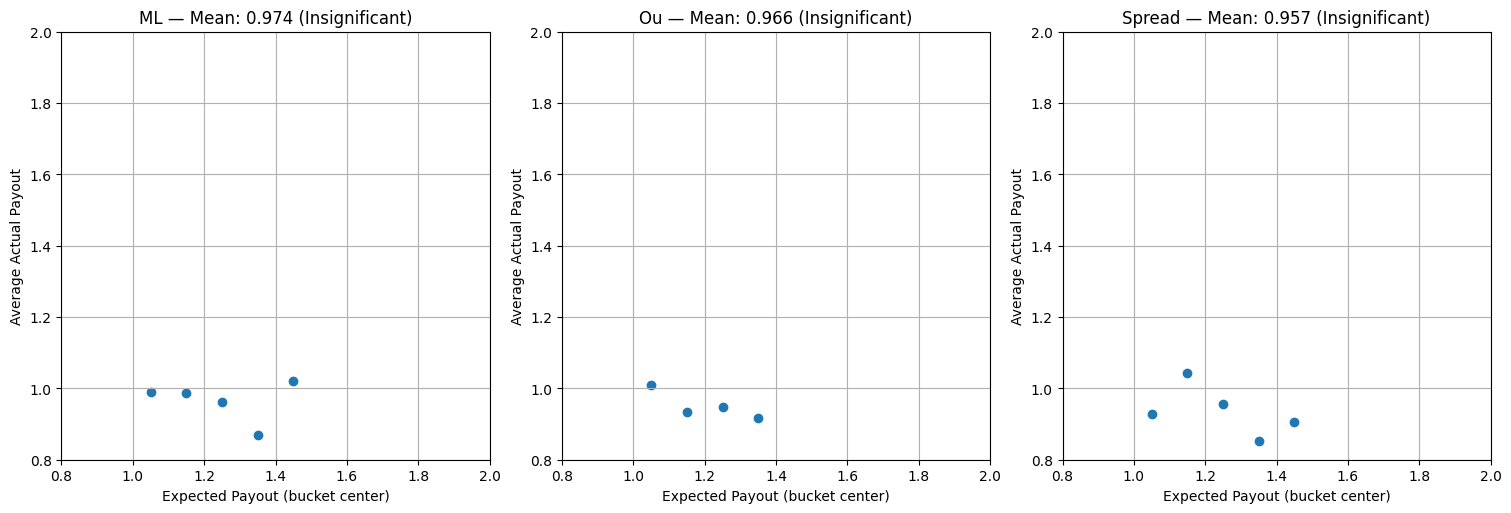

In [35]:
def plot_expected_vs_actual(bet_df, bucket_size=0.05, alpha=0.05):
    positive_ev_df = bet_df[bet_df['PositiveEV'] == 1].copy()

    bins = np.arange(
        positive_ev_df['ExpectedPayout'].min(),
        positive_ev_df['ExpectedPayout'].max() + bucket_size,
        bucket_size
    )
    labels = (bins[:-1] + bins[1:]) / 2

    bet_types = positive_ev_df['BetType'].unique()
    fig, axes = plt.subplots(1, len(bet_types), figsize=(5 * len(bet_types), 5), constrained_layout=True)

    if len(bet_types) == 1:
        axes = [axes]

    for ax, bet_type in zip(axes, bet_types):
        df_bt = positive_ev_df[positive_ev_df['BetType'] == bet_type].copy()
        df_bt['ExpectedPayoutBucket'] = pd.cut(df_bt['ExpectedPayout'], bins=bins, labels=labels, include_lowest=True)

        bucketed = df_bt.groupby('ExpectedPayoutBucket').agg(
            avg_actual_payout=('ActualPayout', 'mean')
        ).dropna()

        # Calculate overall average actual payout & t-test against 1
        actual_payouts = df_bt['ActualPayout'].dropna()
        actual_payouts = pd.to_numeric(actual_payouts, errors='coerce').dropna()

        
        mean_actual = actual_payouts.mean()
        if len(actual_payouts) > 1:
            t_stat, p_val = ttest_1samp(actual_payouts, popmean=1)
            significant = (p_val / 2 < alpha) and (t_stat > 0)
        else:
            significant = False

        signif_text = "Significant" if significant else "Insignificant"

        # Plot scatter
        ax.scatter(bucketed.index.astype(float), bucketed['avg_actual_payout'])
        ax.set_title(f'{bet_type} — Mean: {mean_actual:.3f} ({signif_text})')
        ax.set_xlabel('Expected Payout (bucket center)')
        ax.set_ylabel('Average Actual Payout')
        ax.set_xlim(0.8, 2)
        ax.set_ylim(0.8, 2)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True)

    plt.show()

# Example usage:
plot_expected_vs_actual(bet_df, bucket_size=0.1)


Interpretations:
- For ML bets, when I pick Vegas's favorite, I expect a payout of ExpectedPayout%. They actually received payouts of ActualPayout% across count bets.
- For Ou bets, when I pick the Under, I expect a payout of ExpectedPayout%. They actually received payouts of ActualPayout% across count bets.
- For Spread bets, when I pick a team that Vegas is neutral on (both have the same ML odds), I expect a payout of ExpectedPayout%. They actually received payouts of ActualPayout% across count bets.

##### 1C. Overall Actual Payout

Overall

In [36]:
bet_df['ExpectedPayout'].astype(float).describe()

count   13802.000000
mean        0.961431
std         0.168289
min         0.358789
25%         0.854303
50%         0.955514
75%         1.063623
max         2.101758
Name: ExpectedPayout, dtype: float64

Filter out games with atypical Over/Unders (including the ML and Spread) - these are likely flawed data

In [37]:
bet_df.query('14 > OU > 6').query('PositiveEV == 1')[['ExpectedPayout', 'ActualPayout']].agg('mean')

ExpectedPayout   1.125180
ActualPayout     0.966012
dtype: object

Preferred Bets

In [38]:
cutoff = 1.05
bet_df.query('14 > OU > 6')[bet_df['ExpectedPayout'].astype(float) > cutoff][['ExpectedPayout', 'ActualPayout']].agg('mean')

ExpectedPayout   1.165897
ActualPayout     0.970716
dtype: object

##### 1D. Predicted Cover Rates vs. Actual Cover Rates

In [39]:
bet_df[bet_df['BetResult'] != "Push"].groupby(['BetType', 'BetPick'])[['Cover', 'BetWin']].mean().reset_index()

,BetType,BetPick,Cover,BetWin
0,ML,Favorite,0.551180,0.562713
1,ML,Neither,0.500000,0.500000
2,ML,Underdog,0.448820,0.436860
3,Ou,Over,0.513280,0.484887
4,Ou,Under,0.446257,0.515113
5,Spread,Favorite,0.431655,0.423208
6,Spread,Neither,0.500000,0.500000
7,Spread,Underdog,0.568345,0.576792


Interpretations:
- For ML bets, when I pick Vegas's favorite, I expect them to cover Cover% of the time. That bet actually wins BetWin% of the time.
- For Ou bets, when I pick the over, I expect the over to cover Cover% of the time. That bet actually wins BetWin% of the time.
- For Spread bets, when I pick a team that Vegas is neutral on (both have the same ML odds), I expect them to cover Cover% of the time. That bet actual wins BetWin% of the time.

##### 1E. Favorite Accuracy

In [40]:
print(f"My favorites win {bet_df[(bet_df['BetType'] == 'ML') & (bet_df['ModelDog'] == 'Favorite')]['BetWin'].mean() * 100 :.1f}% of games")
print(f"Vegas's favorites win {bet_df[(bet_df['BetType'] == 'ML') & (bet_df['VegasDog'] == 'Favorite')]['BetWin'].mean() * 100 :.1f}% of games")

My favorites win 53.6% of games
Vegas's favorites win 56.3% of games


### Runs

##### 2A. Totals

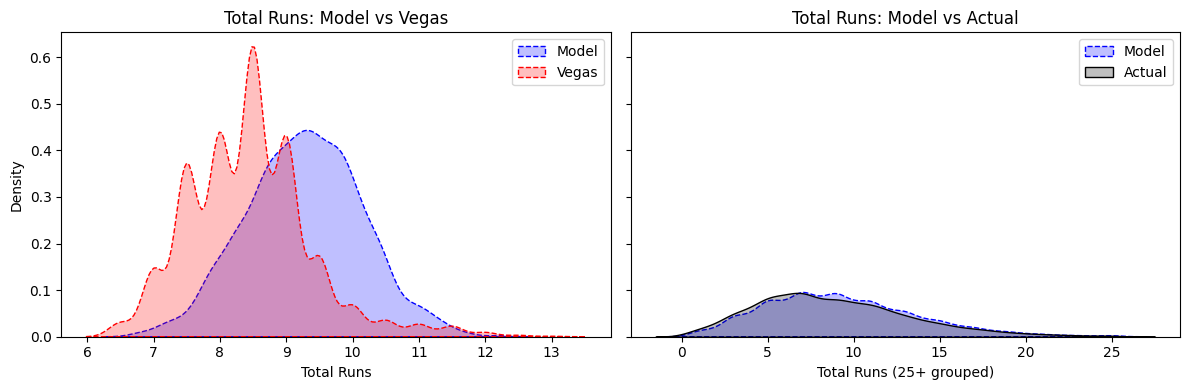

In [41]:
# Filter to valid rows where TotalCounts is a dict and needed columns exist
ml_df = bet_df[(bet_df['BetType'] == 'ML') & (bet_df['TotalCounts'].apply(lambda x: isinstance(x, dict)))].copy()

# Left plot data: continuous scores (Vegas vs Model)
vegas_scores = ml_df['OU'].dropna()
model_scores = ml_df['ModelTotalScore'].dropna()

# Right plot data: expand TotalCounts dicts into samples & actual TotalScore values
sim_samples = []
for d in ml_df['TotalCounts']:
    if not isinstance(d, dict) or len(d) == 0:
        continue
    for score, count in d.items():
        try:
            score_int = int(float(score))  # convert string/float keys safely
            binned_score = score_int if score_int < 25 else 25
            count_int = int(count)
            sim_samples.extend([binned_score] * count_int)
        except Exception as e:
            print(f"Skipping invalid entry: score={score}, count={count}, error={e}")


actual_samples = ml_df['TotalScore'].dropna().astype(int).apply(lambda x: x if x < 25 else 25).tolist()

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Left plot: VegasTotalScore vs ModelTotalScore KDE
sns.kdeplot(model_scores, label='Model', shade=True, ax=axes[0], linestyle='--', color='blue')
sns.kdeplot(vegas_scores, label='Vegas', shade=True, ax=axes[0], linestyle='--', color='red')
axes[0].legend()
axes[0].set_title("Total Runs: Model vs Vegas")
axes[0].set_xlabel("Total Runs")

# Right plot: TotalCounts (sim) vs TotalScore (actual) KDE
sns.kdeplot(sim_samples, label='Model', shade=True, bw_adjust=3, ax=axes[1], linestyle='--', color='blue')
sns.kdeplot(actual_samples, label='Actual', shade=True, ax=axes[1], color='black')
axes[1].legend()
axes[1].set_title("Total Runs: Model vs Actual")
axes[1].set_xlabel("Total Runs (25+ grouped)")

plt.tight_layout()
plt.show()


In [42]:
print(f"Model MSE: {mean_squared_error(bet_df.drop_duplicates('game_id')[['ModelTotalScore', 'OU', 'TotalScore']].dropna()['TotalScore'], bet_df.drop_duplicates('game_id')[['ModelTotalScore', 'OU', 'TotalScore']].dropna()['ModelTotalScore']):.3f}")
print(f"Vegas MSE: {mean_squared_error(bet_df.drop_duplicates('game_id')[['ModelTotalScore', 'OU', 'TotalScore']].dropna()['TotalScore'], bet_df.drop_duplicates('game_id')[['ModelTotalScore', 'OU', 'TotalScore']].dropna()['OU']):.3f}")

Model MSE: 26.520
Vegas MSE: 20.367


##### 2B. Away/Home

Model Average Score

In [43]:
away_model_score = bet_df[(bet_df['BetType'] == "ML") & (bet_df['BetSide'] == "Away")]['ModelScore']
home_model_score = bet_df[(bet_df['BetType'] == "ML") & (bet_df['BetSide'] == "Home")]['ModelScore']

Vegas Score

In [44]:
away_vegas_score = bet_df[(bet_df['BetType'] == "ML") & (bet_df['BetSide'] == "Away")]['VegasScore']
home_vegas_score = bet_df[(bet_df['BetType'] == "ML") & (bet_df['BetSide'] == "Home")]['VegasScore']

Model Run Counts

In [45]:
# Step 1: Ensure Counts column is parsed as dicts
bet_df['Counts'] = bet_df['Counts'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Step 2: Filter for valid ML rows with proper dicts
ml_valid = bet_df[(bet_df['BetType'] == 'ML') & (bet_df['Counts'].apply(lambda x: isinstance(x, dict)))]

# Step 3: Separate filters
away_df = ml_valid[ml_valid['BetSide'] == 'Away']
home_df = ml_valid[ml_valid['BetSide'] == 'Home']

# Step 4: Sum counts into separate dictionaries
away_model_counts_dict = Counter()
for d in away_df['Counts']:
    away_model_counts_dict.update(d)

home_model_counts_dict = Counter()
for d in home_df['Counts']:
    home_model_counts_dict.update(d)

Actual Runs

In [46]:
away_score = bet_df[(bet_df['BetType'] == "ML") & (bet_df['BetSide'] == "Away")]['Score']
home_score = bet_df[(bet_df['BetType'] == "ML") & (bet_df['BetSide'] == "Home")]['Score']

Graph

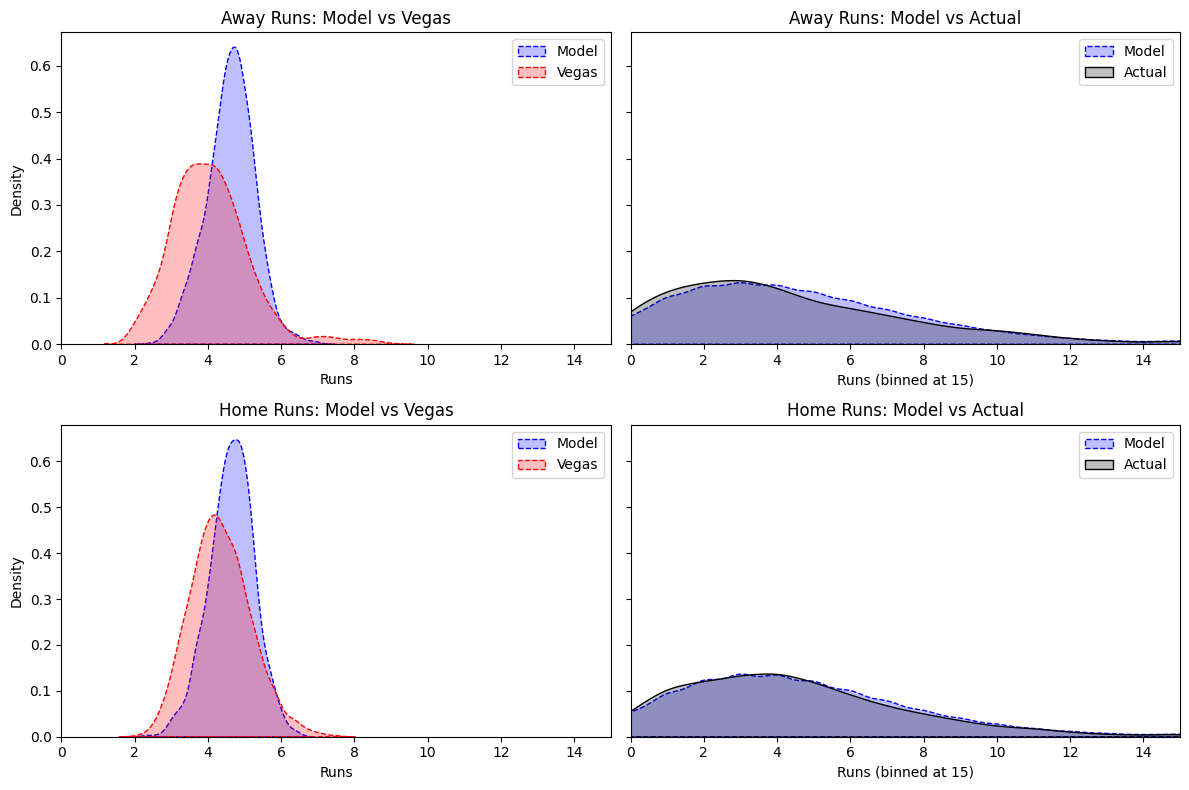

In [47]:
max_bin = 15

# Prepare samples helper
def prepare_samples(counts_dict, max_bin):
    samples = []
    for score, count in counts_dict.items():
        binned_score = score if score <= max_bin else max_bin
        samples.extend([binned_score] * count)
    return samples

# Filter ML + valid dict counts
ml_valid = bet_df[(bet_df['BetType'] == 'ML') & (bet_df['Counts'].apply(lambda x: isinstance(x, dict)))]

away_df = ml_valid[ml_valid['BetSide'] == 'Away']
home_df = ml_valid[ml_valid['BetSide'] == 'Home']

# Sum counts into dictionaries
away_model_counts_dict = Counter()
for d in away_df['Counts']:
    away_model_counts_dict.update(d)

home_model_counts_dict = Counter()
for d in home_df['Counts']:
    home_model_counts_dict.update(d)

# Use your already defined vegas and model scores
away_vegas_score = away_df['VegasScore'].dropna()
away_model_score = away_df['ModelScore'].dropna()

home_vegas_score = home_df['VegasScore'].dropna()
home_model_score = home_df['ModelScore'].dropna()

# Right column: expand counts dict to samples
away_model_samples = prepare_samples(away_model_counts_dict, max_bin)
home_model_samples = prepare_samples(home_model_counts_dict, max_bin)

# Actual scores clipped at max_bin
away_actual_scores = away_score.apply(lambda x: x if x <= max_bin else max_bin).dropna().astype(int).tolist()
home_actual_scores = home_score.apply(lambda x: x if x <= max_bin else max_bin).dropna().astype(int).tolist()

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey='row')

# Top-left: Away ModelScore vs Away VegasScore
sns.kdeplot(away_model_score, label='Model', shade=True, ax=axes[0, 0], linestyle='--', color='blue')
sns.kdeplot(away_vegas_score, label='Vegas', shade=True, ax=axes[0, 0], linestyle='--', color='red')
axes[0, 0].legend()
axes[0, 0].set_title("Away Runs: Model vs Vegas")
axes[0, 0].set_xlim(0, max_bin)
axes[0, 0].set_xlabel("Runs")

# Bottom-left: Home ModelScore vs Home VegasScore
sns.kdeplot(home_model_score, label='Model', shade=True, ax=axes[1, 0], linestyle='--', color='blue')
sns.kdeplot(home_vegas_score, label='Vegas', shade=True, ax=axes[1, 0], linestyle='--',  color='red')
axes[1, 0].legend()
axes[1, 0].set_title("Home Runs: Model vs Vegas")
axes[1, 0].set_xlim(0, max_bin)
axes[1, 0].set_xlabel("Runs")

# Top-right: Away Model Counts dict vs Away Actual Score
sns.kdeplot(away_model_samples, label='Model', shade=True, bw_adjust=3, ax=axes[0, 1], linestyle='--', color='blue')
sns.kdeplot(away_actual_scores, label='Actual', shade=True, ax=axes[0, 1], color='black')
axes[0, 1].legend()
axes[0, 1].set_title("Away Runs: Model vs Actual")
axes[0, 1].set_xlim(0, max_bin)
axes[0, 1].set_xlabel("Runs (binned at 15)")

# Bottom-right: Home Model Counts dict vs Home Actual Score
sns.kdeplot(home_model_samples, label='Model', shade=True, bw_adjust=3, ax=axes[1, 1], linestyle='--', color='blue')
sns.kdeplot(home_actual_scores, label='Actual', shade=True, ax=axes[1, 1], color='black')
axes[1, 1].legend()
axes[1, 1].set_title("Home Runs: Model vs Actual")
axes[1, 1].set_xlim(0, max_bin)
axes[1, 1].set_xlabel("Runs (binned at 15)")

plt.tight_layout()
plt.show()


In [48]:
print(f"Away Model MSE: {mean_squared_error(bet_df[(bet_df['BetType'] == 'ML') & (bet_df['BetSide'] == 'Away')][['away_score', 'ModelScore', 'VegasScore']].dropna()['ModelScore'], bet_df[(bet_df['BetType'] == 'ML') & (bet_df['BetSide'] == 'Away')][['away_score', 'ModelScore', 'VegasScore']].dropna()['away_score'])}")
print(f"Away Vegas MSE: {mean_squared_error(bet_df[(bet_df['BetType'] == 'ML') & (bet_df['BetSide'] == 'Away')][['away_score', 'ModelScore', 'VegasScore']].dropna()['VegasScore'], bet_df[(bet_df['BetType'] == 'ML') & (bet_df['BetSide'] == 'Away')][['away_score', 'ModelScore', 'VegasScore']].dropna()['away_score'])}")
print(f"Home Model MSE: {mean_squared_error(bet_df[(bet_df['BetType'] == 'ML') & (bet_df['BetSide'] == 'Home')][['home_score', 'ModelScore', 'VegasScore']].dropna()['ModelScore'], bet_df[(bet_df['BetType'] == 'ML') & (bet_df['BetSide'] == 'Home')][['home_score', 'ModelScore', 'VegasScore']].dropna()['home_score'])}")
print(f"Home Vegas MSE: {mean_squared_error(bet_df[(bet_df['BetType'] == 'ML') & (bet_df['BetSide'] == 'Home')][['home_score', 'ModelScore', 'VegasScore']].dropna()['VegasScore'], bet_df[(bet_df['BetType'] == 'ML') & (bet_df['BetSide'] == 'Home')][['home_score', 'ModelScore', 'VegasScore']].dropna()['home_score'])}")

Away Model MSE: 11.216982870101928
Away Vegas MSE: 11.032207314272673
Home Model MSE: 9.72638799916143
Home Vegas MSE: 9.49540727551815


##### 2C. Underdog/Favorite

Model Average Score

In [49]:
underdog_model_score = bet_df[(bet_df['BetType'] == "ML") & (bet_df['ModelDog'] == "Underdog")]['ModelScore']
favorite_model_score = bet_df[(bet_df['BetType'] == "ML") & (bet_df['ModelDog'] == "Favorite")]['ModelScore']

Vegas Score

In [50]:
underdog_vegas_score = bet_df[(bet_df['BetType'] == "ML") & (bet_df['VegasDog'] == "Underdog")]['VegasScore']
favorite_vegas_score = bet_df[(bet_df['BetType'] == "ML") & (bet_df['VegasDog'] == "Favorite")]['VegasScore']

Model Run Counts

In [51]:
# Step 1: Ensure Counts column is parsed as dicts
bet_df['Counts'] = bet_df['Counts'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Step 2: Filter for valid ML rows with proper dicts
ml_valid = bet_df[(bet_df['BetType'] == 'ML') & (bet_df['Counts'].apply(lambda x: isinstance(x, dict)))]

# Step 3: Separate filters
underdog_df = ml_valid[ml_valid['ModelDog'] == 'Underdog']
favorite_df = ml_valid[ml_valid['ModelDog'] == 'Favorite']

# Step 4: Sum counts into separate dictionaries
underdog_model_counts_dict = Counter()
for d in away_df['Counts']:
    underdog_model_counts_dict.update(d)

favorite_model_counts_dict = Counter()
for d in home_df['Counts']:
    favorite_model_counts_dict.update(d)

Actual Runs

In [52]:
underdog_score = bet_df[(bet_df['BetType'] == "ML") & (bet_df['ModelDog'] == "Underdog")]['Score']
favorite_score = bet_df[(bet_df['BetType'] == "ML") & (bet_df['ModelDog'] == "Favorite")]['Score']

Graph

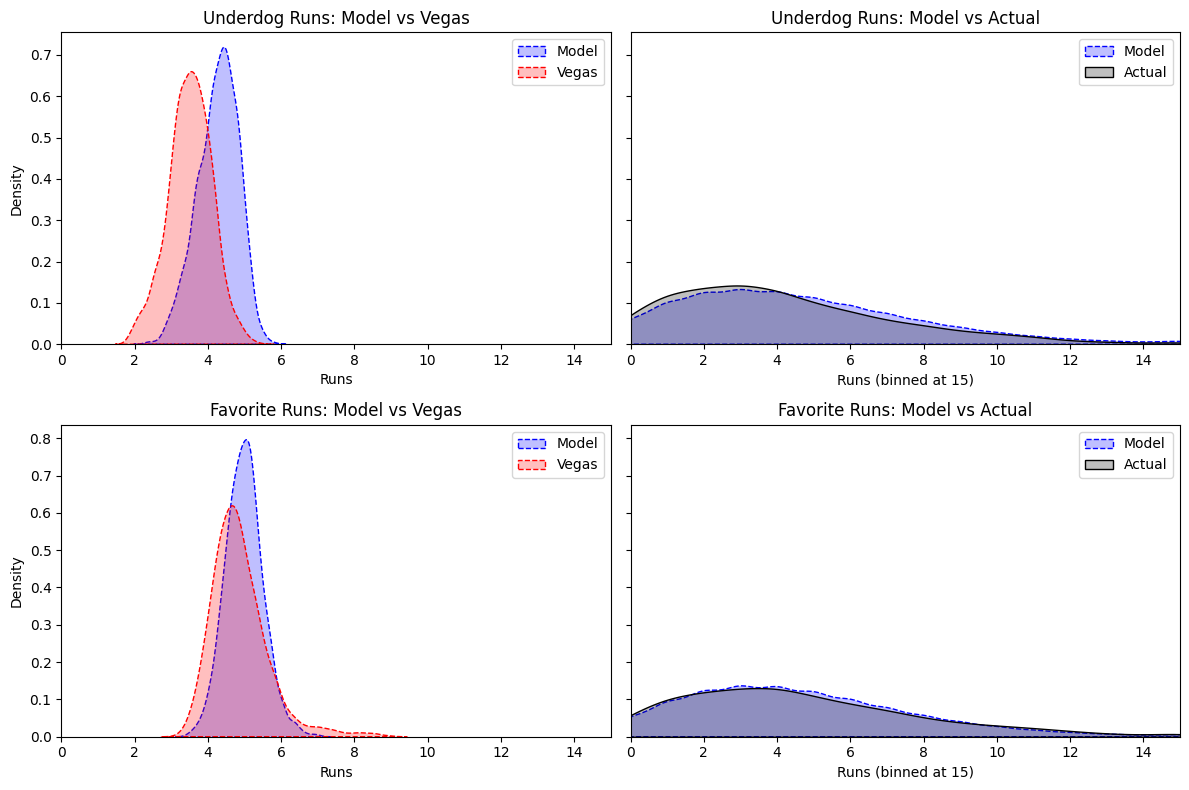

In [53]:
max_bin = 15

# Helper function for expanding counts dict to samples (reuse)
def prepare_samples(counts_dict, max_bin):
    samples = []
    for score, count in counts_dict.items():
        binned_score = score if score <= max_bin else max_bin
        samples.extend([binned_score] * count)
    return samples

# Expand counts dicts into sample lists
underdog_model_samples = prepare_samples(underdog_model_counts_dict, max_bin)
favorite_model_samples = prepare_samples(favorite_model_counts_dict, max_bin)

# Actual scores clipped at max_bin
underdog_actual_scores = underdog_score.apply(lambda x: x if x <= max_bin else max_bin).dropna().astype(int).tolist()
favorite_actual_scores = favorite_score.apply(lambda x: x if x <= max_bin else max_bin).dropna().astype(int).tolist()

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey='row')

# Top-left: Underdog ModelScore vs Underdog VegasScore
sns.kdeplot(underdog_model_score, label='Model', shade=True, ax=axes[0, 0], linestyle='--', color='blue')
sns.kdeplot(underdog_vegas_score, label='Vegas', shade=True, ax=axes[0, 0], linestyle='--', color='red')
axes[0, 0].legend()
axes[0, 0].set_title("Underdog Runs: Model vs Vegas")
axes[0, 0].set_xlim(0, max_bin)
axes[0, 0].set_xlabel("Runs")

# Bottom-left: Favorite ModelScore vs Favorite VegasScore
sns.kdeplot(favorite_model_score, label='Model', shade=True, ax=axes[1, 0], linestyle='--', color='blue')
sns.kdeplot(favorite_vegas_score, label='Vegas', shade=True, ax=axes[1, 0], linestyle='--', color='red')
axes[1, 0].legend()
axes[1, 0].set_title("Favorite Runs: Model vs Vegas")
axes[1, 0].set_xlim(0, max_bin)
axes[1, 0].set_xlabel("Runs")

# Top-right: Underdog Model Counts dict vs Underdog Actual Score
sns.kdeplot(underdog_model_samples, label='Model', shade=True, bw_adjust=3, ax=axes[0, 1], linestyle='--', color='blue')
sns.kdeplot(underdog_actual_scores, label='Actual', shade=True, ax=axes[0, 1], color='black')
axes[0, 1].legend()
axes[0, 1].set_title("Underdog Runs: Model vs Actual")
axes[0, 1].set_xlim(0, max_bin)
axes[0, 1].set_xlabel("Runs (binned at 15)")

# Bottom-right: Favorite Model Counts dict vs Favorite Actual Score
sns.kdeplot(favorite_model_samples, label='Model', shade=True, bw_adjust=3, ax=axes[1, 1], linestyle='--', color='blue')
sns.kdeplot(favorite_actual_scores, label='Actual', shade=True, ax=axes[1, 1], color='black')
axes[1, 1].legend()
axes[1, 1].set_title("Favorite Runs: Model vs Actual")
axes[1, 1].set_xlim(0, max_bin)
axes[1, 1].set_xlabel("Runs (binned at 15)")

plt.tight_layout()
plt.show()

In [54]:
print(f"Underdog Model MSE: {mean_squared_error(bet_df[(bet_df['BetType'] == 'ML') & (bet_df['ModelDog'] == 'Underdog')][['Score', 'ModelScore', 'VegasScore']].dropna()['ModelScore'], bet_df[(bet_df['BetType'] == 'ML') & (bet_df['ModelDog'] == 'Underdog')][['Score', 'ModelScore', 'VegasScore']].dropna()['Score'])}")
print(f"Underdog Vegas MSE: {mean_squared_error(bet_df[(bet_df['BetType'] == 'ML') & (bet_df['VegasDog'] == 'Underdog')][['Score', 'ModelScore', 'VegasScore']].dropna()['VegasScore'], bet_df[(bet_df['BetType'] == 'ML') & (bet_df['VegasDog'] == 'Underdog')][['Score', 'ModelScore', 'VegasScore']].dropna()['Score'])}")
print(f"Favorite Model MSE: {mean_squared_error(bet_df[(bet_df['BetType'] == 'ML') & (bet_df['ModelDog'] == 'Favorite')][['Score', 'ModelScore', 'VegasScore']].dropna()['ModelScore'], bet_df[(bet_df['BetType'] == 'ML') & (bet_df['ModelDog'] == 'Favorite')][['Score', 'ModelScore', 'VegasScore']].dropna()['Score'])}")
print(f"Favorite Vegas MSE: {mean_squared_error(bet_df[(bet_df['BetType'] == 'ML') & (bet_df['VegasDog'] == 'Favorite')][['Score', 'ModelScore', 'VegasScore']].dropna()['VegasScore'], bet_df[(bet_df['BetType'] == 'ML') & (bet_df['VegasDog'] == 'Favorite')][['Score', 'ModelScore', 'VegasScore']].dropna()['Score'])}")

Underdog Model MSE: 9.81591224920609
Underdog Vegas MSE: 10.305666501780749
Favorite Model MSE: 11.120009643728158
Favorite Vegas MSE: 10.302949097331286


In [55]:
bet_df.groupby('ModelDog')[['ModelScore', 'Score']].mean()

,ModelScore,Score
ModelDog,,
Favorite,4.995862,4.675262
Neither,4.822453,4.485876
Underdog,4.278593,4.193619


In [56]:
bet_df.groupby('VegasDog')[['VegasScore', 'Score']].mean()

,VegasScore,Score
VegasDog,,
Favorite,4.877987,4.732935
Neither,4.252083,4.425620
Underdog,3.521295,4.144625


Interpretation: <br>
Projected scores close to actual scores suggest that model favorites and underdogs are not biased toward the mean or an extreme

##### 2D. Victory Margin

Model Margin

In [57]:
bet_df['ModelMargin'] = abs(bet_df['ModelScore1'] - bet_df['ModelScore2'])
model_margin = bet_df.drop_duplicates(subset=['game_id'], keep='first')['ModelMargin']

Vegas Margin

In [58]:
bet_df['VegasMargin'] = abs(bet_df['VegasScore1'] - bet_df['VegasScore2'])
vegas_margin = bet_df.drop_duplicates('game_id', keep='first')['VegasMargin'].dropna()

Model Counts

In [59]:
# Step 1: Ensure MarginCounts column is parsed as dicts
bet_df['MarginCounts'] = bet_df['MarginCounts'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Step 2: Filter only valid dict rows
valid_margin_df = bet_df.drop_duplicates('game_id', keep='first')[bet_df['MarginCounts'].apply(lambda x: isinstance(x, dict))]

# Step 3: Sum all MarginCounts into one dictionary
margin_counts_dict = Counter()
for d in valid_margin_df['MarginCounts']:
    margin_counts_dict.update(d)

Actual Margin

In [60]:
bet_df['Margin'] = abs(bet_df['away_score'] - bet_df['home_score'])
actual_margin = bet_df['Margin']

Margin Table

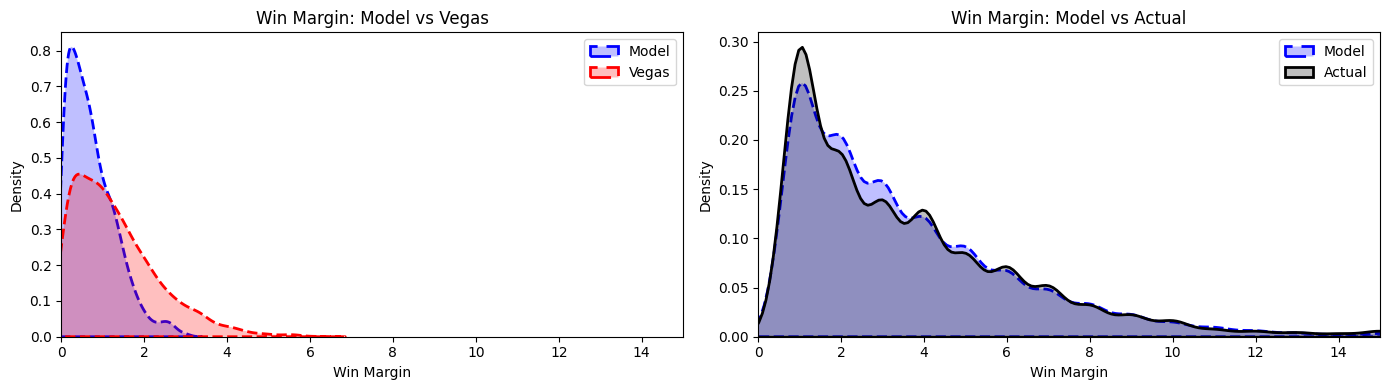

In [61]:
# Settings
max_bin = 15

# Expand counts dict into sample list, capping values at max_bin
def expand_positive_counts(counts_dict, max_bin):
    samples = []
    for margin, count in counts_dict.items():
        binned = margin if margin <= max_bin else max_bin
        samples.extend([binned] * count)
    return samples

# Prepare model vs actual samples
sim_samples = expand_positive_counts(margin_counts_dict, max_bin)
actual_binned = [m if m <= max_bin else max_bin for m in actual_margin]

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: Model vs Vegas (KDE)
sns.kdeplot(model_margin, label='Model', shade=True, ax=axes[0], color='blue', linestyle='--', linewidth=2)
sns.kdeplot(vegas_margin, label='Vegas', shade=True, ax=axes[0], color='red', linestyle='--', linewidth=2)
axes[0].legend()
axes[0].set_title("Win Margin: Model vs Vegas")
axes[0].set_xlabel("Win Margin")
axes[0].set_xlim(0, max_bin)

# Right: Simulated vs Actual (KDE)
sns.kdeplot(sim_samples, label='Model', shade=True, ax=axes[1], color='blue', bw_adjust=3, linestyle='--', linewidth=2)
sns.kdeplot(actual_binned, label='Actual', shade=True, ax=axes[1], color='black', bw_adjust=1, linewidth=2)
axes[1].legend()
axes[1].set_title("Win Margin: Model vs Actual")
axes[1].set_xlabel("Win Margin")
axes[1].set_xlim(0, max_bin)

plt.tight_layout()
plt.show()

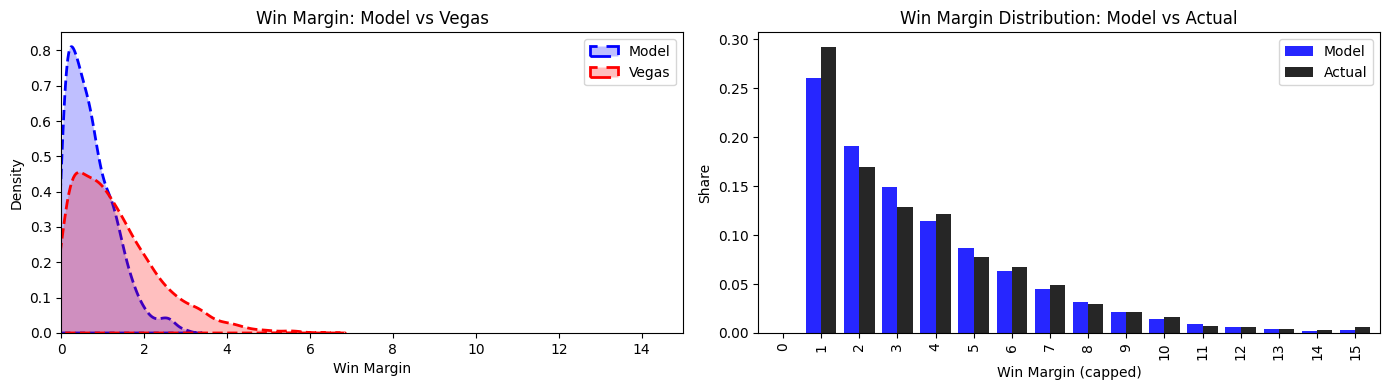

In [62]:
# Compute normalized value counts
sim_vc = pd.Series(sim_samples).value_counts(normalize=True)
actual_vc = pd.Series(actual_binned).value_counts(normalize=True)

# Align index
all_index = sim_vc.index.union(actual_vc.index)

df_plot = pd.DataFrame({
    'Model': sim_vc.reindex(all_index, fill_value=0),
    'Actual': actual_vc.reindex(all_index, fill_value=0),
}).sort_index()

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: Model vs Vegas (KDE)
sns.kdeplot(model_margin, label='Model', shade=True, ax=axes[0], color='blue', linestyle='--', linewidth=2)
sns.kdeplot(vegas_margin, label='Vegas', shade=True, ax=axes[0], color='red', linestyle='--', linewidth=2)
axes[0].legend()
axes[0].set_title("Win Margin: Model vs Vegas")
axes[0].set_xlabel("Win Margin")
axes[0].set_xlim(0, max_bin)

# Right: Simulated vs Actual (Bar Chart)
df_plot.plot(
    kind='bar',
    ax=axes[1],
    width=0.8,
    alpha=0.85,
    color=['blue', 'black']   # Sim = blue, Actual = black

)

axes[1].set_title("Win Margin Distribution: Model vs Actual")
axes[1].set_xlabel("Win Margin (capped)")
axes[1].set_ylabel("Share")
axes[1].legend()

plt.tight_layout()
plt.show()


In [63]:
sim_vc = pd.Series(sim_samples).value_counts(normalize=True)
actual_vc = pd.Series(actual_margin).value_counts(normalize=True)

all_index = sim_vc.index.union(actual_vc.index)

pd.DataFrame({
    'Sim': sim_vc.reindex(all_index, fill_value=0),
    'Actual': actual_vc.reindex(all_index, fill_value=0),
}).sort_index()


,Sim,Actual
0,0.000000,0.000406
1,0.260273,0.292495
2,0.191315,0.169980
3,0.148806,0.128195
4,0.114510,0.121704
5,0.086305,0.077890
6,0.063185,0.066937
7,0.045126,0.048682
8,0.031306,0.030020
9,0.021296,0.021095


##### 2E. Time

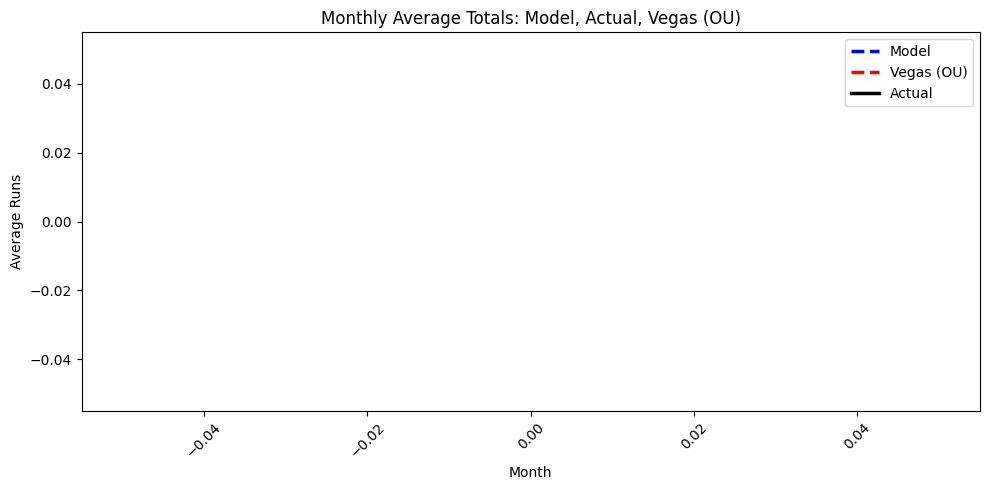

In [64]:
# Step 1: Drop duplicates on game_id
bet_df['game_datetime'] = pd.to_datetime(bet_df['game_datetime'])

bet_unique = bet_df[bet_df['game_datetime'].dt.month.between(4, 9)].drop_duplicates(subset='game_id').copy()

# Step 2: Ensure game_datetime is a datetime object and extract year-month
bet_unique['game_datetime'] = pd.to_datetime(bet_unique['game_datetime'])
bet_unique['YearMonth'] = bet_unique['game_datetime'].dt.to_period('M')

# Step 3: Filter for April 2024 and later
bet_filtered = bet_unique[(bet_unique['YearMonth'] >= '2024-04') & (bet_unique['YearMonth'] <= '2024-10')]

# Step 4: Group by month and compute averages
monthly_avg = bet_filtered.groupby('YearMonth')[['ModelTotalScore', 'TotalScore', 'OU']].mean().reset_index()
monthly_avg['YearMonth'] = monthly_avg['YearMonth'].astype(str)  # for plotting

# Step 5: Plotting with custom styles
plt.figure(figsize=(10, 5))

# Plot with specific colors and line styles
plt.plot(monthly_avg['YearMonth'], monthly_avg['ModelTotalScore'], label='Model', color='blue', linestyle='--', lw=2.5)
plt.plot(monthly_avg['OU'], label='Vegas (OU)', color='red', linestyle='--', lw=2.5)
plt.plot(monthly_avg['YearMonth'], monthly_avg['TotalScore'], label='Actual', color='black', linestyle='-', lw=2.5)  # solid line

plt.xticks(rotation=45)
plt.title("Monthly Average Totals: Model, Actual, Vegas (OU)")
plt.xlabel("Month")
plt.ylabel("Average Runs")
plt.legend()
plt.tight_layout()
plt.show()

##### 2F. Venue

In [65]:
# Drop duplicate games first
unique_games = bet_df.drop_duplicates(subset=['game_id'])

# Group by venue and aggregate
agg_df = unique_games.groupby(['venue_id', 'venue_name']).agg(
    ModelTotalScore=('ModelTotalScore', 'mean'),
    TotalScore=('TotalScore', 'mean'),
    OU=('OU', 'mean'),
    count=('game_id', 'count')
).reset_index()

# Filter venues with more than 10 observations
agg_df_filtered = agg_df[agg_df['count'] > 10].copy()

# Calculate difference
agg_df_filtered['Diff'] = agg_df_filtered['ModelTotalScore'] - agg_df_filtered['TotalScore']

# Your color function (unchanged)
def color_diff(val):
    max_val = 2  # fixed range from -2 to 2
    percent = min(abs(val) / max_val, 1) * 50  # cap at 1 to avoid overflow

    if val > 0:
        return f"""
            background: linear-gradient(to right, transparent 50%, red 50%, red {50 + percent}%, transparent {50 + percent}%);
            color: black;
        """
    elif val < 0:
        return f"""
            background: linear-gradient(to left, transparent 50%, blue 50%, blue {50 + percent}%, transparent {50 + percent}%);
            color: black;
        """
    else:
        return ''



# Apply styling to the filtered DataFrame
styled = agg_df_filtered.style.applymap(color_diff, subset=['Diff'])


print(f"Bias: {agg_df_filtered['Diff'].mean()}")
print(f"MSE: {((agg_df_filtered['Diff'])**2).mean()}")

styled

Bias: -0.20129168022550858
MSE: 0.6881454490686411


,venue_id,venue_name,ModelTotalScore,TotalScore,OU,count,Diff
0,1,Angel Stadium,9.442957,9.400000,8.818750,80,0.042957
1,2,Oriole Park at Camden Yards,8.711167,9.296296,8.895062,81,-0.585130
2,3,Fenway Park,7.913219,8.987654,8.808642,81,-1.074436
3,4,Rate Field,7.953185,8.493827,8.265432,81,-0.540642
4,5,Progressive Field,8.809076,7.975904,7.861446,83,0.833173
5,7,Kauffman Stadium,9.017433,7.518519,8.481481,81,1.498915
6,14,Rogers Centre,8.171864,9.573034,8.202247,89,-1.401170
7,15,Chase Field,9.520959,9.700000,8.918750,80,-0.179041
8,17,Wrigley Field,8.396237,8.650602,7.951807,83,-0.254365
9,19,Coors Field,10.253448,11.716049,10.962963,81,-1.462601


In [66]:
all_filename, all_adjusted_filename

('predict_all_256128_69066_20260123', 'predict_all_adjusted_32_87308_20251211')

In [67]:
output_name = f"E01. Evaluate Games {datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.html"
output_dir = os.path.join(baseball_path, "E01. Evaluate Games")

!"{sys.executable}" -m jupyter nbconvert --to html "E01. Evaluate Games.ipynb" --output "{output_name}" --output-dir "{output_dir}"

[NbConvertApp] Converting notebook E01. Evaluate Games.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 1089659 bytes to C:\Users\James\Documents\MLB\Data\E01. Evaluate Games\E01. Evaluate Games 2026-02-13_13-09-46.html
